# MAQT & Encoder Lipschitz $L_\varphi$
## BoT-IoT | Capped Sample (700) | ~2800 Train | Batch Size 64 | 10 Epochs | LR 0.05
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from pennylane import numpy as np

In [2]:
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.constants import (
    DEFAULT_BATCH_SIZE,
    DEFAULT_LAMBDA1,
    DEFAULT_LAMBDA2,
    DEFAULT_LR,
    DEFAULT_NOISE_RATE,
    # DEFAULT_DELTA,  # deprecated
)
from scripts.data import (
    capped_sample,
    load_split,
    plot_class_balance_pie,
)
from scripts.logging import write_history_log

# from scripts.inference import estimate_lipschitz  # deprecated
from scripts.theory import (
    analytic_lipschitz_bound,
    check_lipschitz_tightness,
    estimate_lipschitz_percentile,
)
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: BoT-IoT

In [4]:
NOTEBOOK_NAME = "16.estimate-lipschitz_bot-iot"
dataset = "BoT-IoT"
split_prefix = "q8"
target_col = "label_multiclass"
data_path = f"data/{dataset}/quantum"

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,rate,n_bytes_total,rate_src,dst_pkts,n_pkts_total,dst_bytes,src_bytes,src_pkts,label_multiclass,label_binary,label_family
0,0.030780,0.332164,0.032406,0.0000,0.295669,0.000000,0.395761,0.295669,DoS,1,dos
1,0.040153,0.429708,0.042274,0.0000,0.404791,0.000000,0.491098,0.404791,DoS,1,dos
2,0.114465,0.476056,0.120511,0.0000,0.458797,0.000000,0.536396,0.458797,DDoS,1,ddos
3,0.051103,0.527890,0.053802,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos
4,0.018999,0.421771,0.020003,0.0000,0.186546,0.000000,0.483341,0.186546,DoS,1,dos
...,...,...,...,...,...,...,...,...,...,...,...
130133,0.051554,0.337622,0.054277,0.0000,0.109122,0.000000,0.401096,0.109122,DDoS,1,ddos
130134,0.077777,0.495858,0.081885,0.0000,0.482215,0.000000,0.555750,0.482215,DDoS,1,ddos
130135,0.085139,0.332164,0.089636,0.0000,0.295669,0.000000,0.395761,0.295669,DDoS,1,ddos
130136,0.034507,0.527890,0.036329,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos


In [6]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,rate,n_bytes_total,rate_src,dst_pkts,n_pkts_total,dst_bytes,src_bytes,src_pkts,label_multiclass,label_binary,label_family
0,0.030780,0.332164,0.032406,0.0000,0.295669,0.000000,0.395761,0.295669,DoS,1,dos
1,0.040153,0.429708,0.042274,0.0000,0.404791,0.000000,0.491098,0.404791,DoS,1,dos
2,0.114465,0.476056,0.120511,0.0000,0.458797,0.000000,0.536396,0.458797,DDoS,1,ddos
3,0.051103,0.527890,0.053802,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos
4,0.018999,0.421771,0.020003,0.0000,0.186546,0.000000,0.483341,0.186546,DoS,1,dos
...,...,...,...,...,...,...,...,...,...,...,...
130133,0.051554,0.337622,0.054277,0.0000,0.109122,0.000000,0.401096,0.109122,DDoS,1,ddos
130134,0.077777,0.495858,0.081885,0.0000,0.482215,0.000000,0.555750,0.482215,DDoS,1,ddos
130135,0.085139,0.332164,0.089636,0.0000,0.295669,0.000000,0.395761,0.295669,DDoS,1,ddos
130136,0.034507,0.527890,0.036329,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos


In [7]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['DDoS', 'DoS', 'Normal', 'Reconnaissance']

In [8]:
# load all data
X_train_full, y_train_full = load_split(
    data_path, f"{split_prefix}_train", target_col, class_names
)

In [9]:
# check shape
[X_train_full.shape, y_train_full.shape]

[(130138, 8), (130138,)]

## EDA (Before Subset)

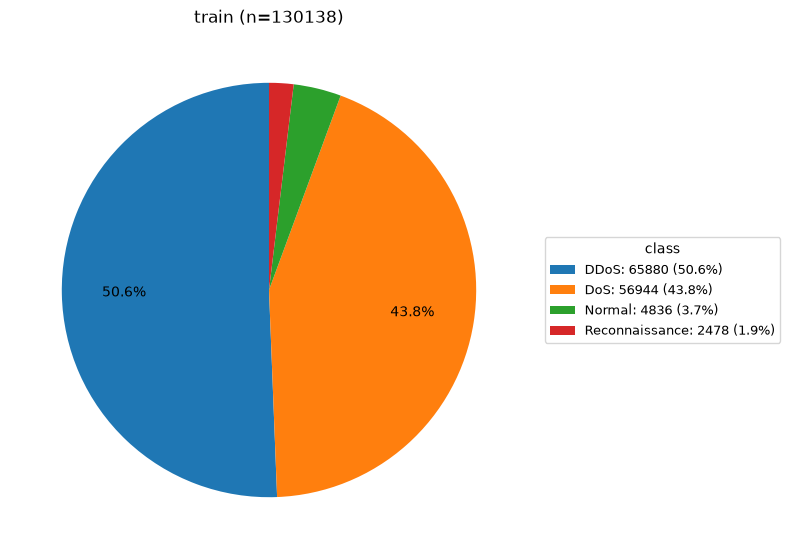

In [10]:
# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_train_full,
    class_names,
    title=f"train (n={len(to_np_y(y_train_full))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

## Data Subset

In [11]:
SUBSET = True  # set to False for the full dataset
SEED = 42
PER_CLASS_CAP = 700

In [12]:
if SUBSET is True:
    X_train, y_train = capped_sample(
        X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED
    )
else:
    X_train, y_train = X_train_full, y_train_full

# check shape
[X_train.shape, y_train.shape]

[(2800, 8), (2800,)]

## EDA (After Subset)

In [13]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

number of classes: 4
number of qubits: 8


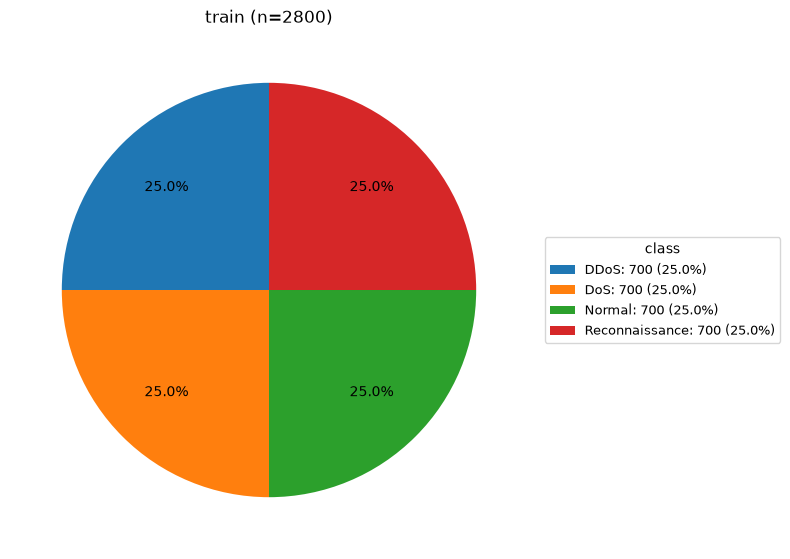

In [14]:
# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_train,
    class_names,
    title=f"train (n={len(to_np_y(y_train))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise


In [15]:
num_layers = 2  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [16]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(
    num_qubits
)  # or dev = qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(
    dev, num_qubits, num_layers, noise_rate=noise_rate
)

## Training

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

Procedure:
- Load the Day-16 MAQT checkpoint if present.
- Set `LOAD_CHECKPOINT=False` only to train a fresh $\theta^\star$ with the same protocol on every dataset (`capped_sample` + weighted sampler + 10 epochs).

In [17]:
LOAD_CHECKPOINT = True
CHECKPOINT_CANDIDATES = [
    Path("artifacts") / dataset / f"{NOTEBOOK_NAME}-checkpoint.pt",
]

epochs = 10
batch_size = DEFAULT_BATCH_SIZE
lr = DEFAULT_LR
lambda1 = DEFAULT_LAMBDA1
lambda2 = DEFAULT_LAMBDA2

In [18]:
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
history = {}
head = None

# use model checkpoint if loading is enabled and a valid file exists
if LOAD_CHECKPOINT and ckpt_path is not None:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    theta_star = ckpt["theta"].to(device)
    if not isinstance(theta_star, torch.nn.Parameter):
        theta_star = torch.nn.Parameter(theta_star)
    prototypes = {int(k): v.to(device) for k, v in ckpt["prototypes"].items()}
    noise_rate = float(ckpt.get("noise_rate", noise_rate))
    num_layers = int(ckpt.get("num_layers", num_layers))
    forward_circuit = build_forward_circuit(
        dev, num_qubits, num_layers, noise_rate=noise_rate
    )
    print(f"loaded checkpoint: {ckpt_path}")
    print(f"theta shape: {tuple(theta_star.shape)} | prototypes: {len(prototypes)}")

# train from scratch if checkpoint loading is disabled or no checkpoint exists
else:
    if LOAD_CHECKPOINT:
        print("checkpoint not found; falling back to MAQT train")

    # exact replica of previous Day-16 training:
    theta, head, prototypes, ema_protos, history = train_maqt(
        X_train,
        y_train,
        n_classes=num_classes,
        n_qubits=num_qubits,
        n_layers=num_layers,
        forward_circuit=forward_circuit,
        device=device,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size,
        lambda1_max=lambda1,
        lambda2_max=lambda2,
        use_weighted_sampler=True,
    )
    theta_star = theta
    print(
        f"trained encoder: theta shape={tuple(theta_star.shape)} | prototypes={len(prototypes)}"
    )

loaded checkpoint: artifacts/BoT-IoT/16.estimate-lipschitz_bot-iot-checkpoint.pt
theta shape: (2, 8, 3) | prototypes: 4


## Algo 3: Unified Inference with Disentangled Rejection

At test time, one pass produces either
- a class label with a certified robustness radius $\rightarrow$ `(label, certified_radius)`, or
- a zero-day flag $\rightarrow$ `(ZERO_DAY, 0)`.

The certified radius uses the encoder Lipschitz constant $L_\varphi$:
$$
R = \frac{m}{2(1-p)\,L_\varphi\,C_f}.
$$

## $L_\varphi$ Estimator

For estimated,
$$
\hat L_\varphi
= \mathrm{Percentile}_{95}
\left\{
\frac{D_{\mathrm{tr}}\big(\rho(x),\,\rho(x')\big)}{||{x-x'}||_2}
\right\}.
$$

For analytical (certified) bound,

$$
L_\varphi = R/2.
$$

In [19]:
# L_phi tuning knobs

# deprecated
# n_probe = 128                 # larger than DEFAULT_N_PROBE (=30) for a stabler distribution
# delta = DEFAULT_DELTA         # DEFAULT_DELTA = 0.05

n_pairs = 300
percentile = 95
seed = SEED

torch.manual_seed(seed)
np.random.seed(seed)

In [20]:
# estimate Lipschitz constant (95th percentile + full ratio distribution)
tightness_diagnostic = estimate_lipschitz_percentile(
    X_train,
    theta_star,
    forward_circuit,
    n_pairs=n_pairs,
    device=device,
    percentile=percentile,
    seed=seed,
)

L_phi_estimated = tightness_diagnostic[f"p{percentile:g}"]
ratios = tightness_diagnostic["ratios"]

L_phi_max = float(np.max(ratios))
L_phi_mean = float(np.mean(ratios))
L_phi_median = float(np.median(ratios))
L_phi_analytic = analytic_lipschitz_bound(num_layers, reupload=True)  # L_phi = R/2

# check tightness
tightness = check_lipschitz_tightness(tightness_diagnostic, L_phi_analytic)

print(f"dataset                  : {dataset}")
# print(f"n_probe / delta   : {len(ratios)} / {delta}") # deprecated
print(f"n_pairs                  : {n_pairs}")
print(f"L_phi (p{percentile})    : {L_phi_estimated:.4f}")
print(f"L_phi (analytic)         : {L_phi_analytic:.4f}")
print(f"L_phi (max)              : {L_phi_max:.4f}")
print(f"L_phi (mean/med)         : {L_phi_mean:.4f} / {L_phi_median:.4f}")
print(f"within analytic bound?   : {tightness['within_bound']}")
print(f"tightness gap (bound-max): {tightness['tightness_gap']:.4f}")

dataset                  : BoT-IoT
n_pairs                  : 300
L_phi (p95)    : 0.6792
L_phi (analytic)         : 1.0000
L_phi (max)              : 0.7001
L_phi (mean/med)         : 0.5536 / 0.5909
within analytic bound?   : True
tightness gap (bound-max): 0.2999


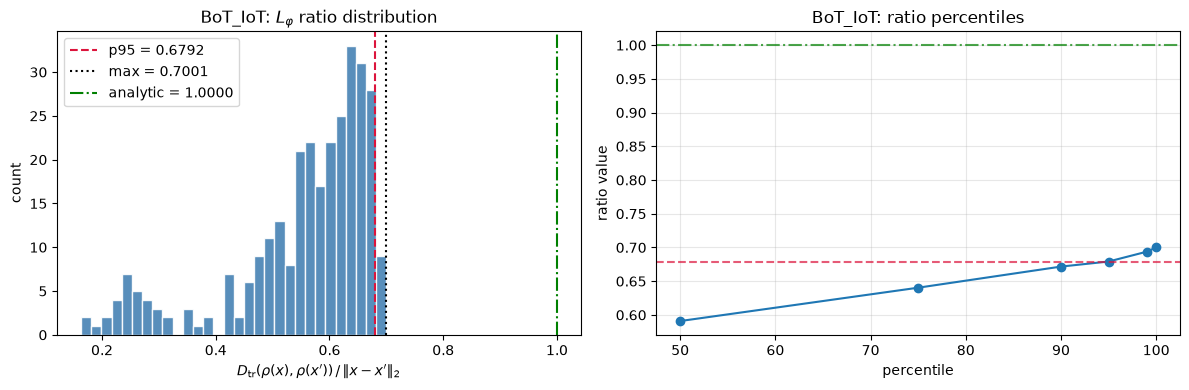

In [21]:
# plot L_phi with its distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ratios, bins=30, color="steelblue", edgecolor="white", alpha=0.9)
axes[0].axvline(
    L_phi_estimated,
    color="crimson",
    linestyle="--",
    label=f"p{percentile} = {L_phi_estimated:.4f}",
)
axes[0].axvline(L_phi_max, color="black", linestyle=":", label=f"max = {L_phi_max:.4f}")
axes[0].axvline(
    L_phi_analytic,
    color="green",
    linestyle="-.",
    label=f"analytic = {L_phi_analytic:.4f}",
)
axes[0].set_xlabel(r"$D_{\mathrm{tr}}(\rho(x),\rho(x'))\,/\,\|x-x'\|_2$")
axes[0].set_ylabel("count")
axes[0].set_title(rf"{dataset}: $L_\varphi$ ratio distribution")
axes[0].legend()

q = np.percentile(ratios, [50, 75, 90, 95, 99, 100])
axes[1].plot([50, 75, 90, 95, 99, 100], q, marker="o")
axes[1].axhline(L_phi_estimated, color="crimson", linestyle="--", alpha=0.7)
axes[1].axhline(L_phi_analytic, color="green", linestyle="-.", alpha=0.7)
axes[1].set_xlabel("percentile")
axes[1].set_ylabel("ratio value")
axes[1].set_title(rf"{dataset}: ratio percentiles")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
ratio_df = pd.DataFrame(
    {
        "stat": [
            "n_pairs",
            f"L_phi (p{percentile})",
            "L_phi (analytic)",
            "p50",
            "p75",
            "p90",
            "p95",
            "p99",
            "max",
            "mean",
        ],
        "value": [
            n_pairs,
            L_phi_estimated,
            L_phi_analytic,
            float(np.percentile(ratios, 50)),
            float(np.percentile(ratios, 75)),
            float(np.percentile(ratios, 90)),
            float(np.percentile(ratios, 95)),
            float(np.percentile(ratios, 99)),
            L_phi_max,
            L_phi_mean,
        ],
    }
)
ratio_df

,stat,value
0,n_pairs,300.000000
1,L_phi (p95),0.679179
2,L_phi (analytic),1.000000
3,p50,0.590921
4,p75,0.640360
5,p90,0.671650
6,p95,0.679179
7,p99,0.693706
8,max,0.700105
9,mean,0.553611


## Logging


In [23]:
# save encoder checkpoint + L_phi artifact
out_dir = Path("artifacts") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

ckpt_path = out_dir / f"{NOTEBOOK_NAME}-checkpoint.pt"

# only save or rewrite checkpoint after a fresh train (head is set)
if head is not None:
    torch.save(
        {
            "theta": theta_star.detach().cpu(),
            "head_state_dict": head.state_dict(),
            "prototypes": {k: v.detach().cpu() for k, v in prototypes.items()},
            # minimal rebuild / inference meta
            "class_names": list(class_names),
            "num_classes": num_classes,
            "num_qubits": num_qubits,
            "num_layers": num_layers,
            "noise_rate": noise_rate,
        },
        ckpt_path,
    )
    print("published checkpoint:", ckpt_path.resolve())
else:
    print("skipped checkpoint overwrite (loaded existing encoder)")

# save L_phi artifact
artifact = {
    "L_phi_estimated": float(L_phi_estimated),
    "L_phi_analytic": float(L_phi_analytic),
    "L_phi_percentile": float(percentile),
    "L_phi_max": float(L_phi_max),
    "L_phi_mean": float(L_phi_mean),
    "L_phi_median": float(L_phi_median),
    "ratios": ratios.tolist(),
    "n_pairs": int(n_pairs),
    "num_layers": int(num_layers),
    "reupload": True,
    "within_analytic_bound": bool(tightness["within_bound"]),
}

lphi_path = out_dir / f"{NOTEBOOK_NAME}-lphi.pt"
torch.save(artifact, lphi_path)
print("published L_phi:     ", lphi_path.resolve())

skipped checkpoint overwrite (loaded existing encoder)
published L_phi:      /home/lawun330/Desktop/quantum-sentinel/artifacts/BoT-IoT/16.estimate-lipschitz_bot-iot-lphi.pt


In [24]:
# write log (final)
log_path = write_history_log(
    history,
    NOTEBOOK_NAME,
    extra={
        ## data
        "data_path": data_path,
        "dataset": dataset,
        "split_prefix": split_prefix,
        "target_col": target_col,
        "n_train": len(X_train),
        "per_class_cap": PER_CLASS_CAP if SUBSET else None,
        "class_names": list(class_names),
        ## algo 1: MAQT train
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,
        "use_weighted_sampler": True,
        ## quantum model
        "noise_rate": noise_rate,
        "num_layers": num_layers,
        "num_qubits": num_qubits,
        "num_classes": num_classes,
        ## L_phi estimator
        "L_phi_estimated": float(L_phi_estimated),
        "L_phi_analytic": float(L_phi_analytic),
        "L_phi_percentile": float(percentile),
        "L_phi_max": float(L_phi_max),
        "L_phi_mean": float(L_phi_mean),
        "n_pairs": int(n_pairs),
        "checkpoint": str(ckpt_path),
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/quantum-sentinel/logs/16.estimate-lipschitz_bot-iot.log
